In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
try:
    import seaborn as sns
    HAS_SNS = True
except Exception:
    HAS_SNS = False

### 1. csv 읽기

In [4]:
TRAIN_PATH = "../data/train.csv"
TEST_PATH = "../data/test.csv"
TARGET_COL = "avg_delay_minutes_next_30m"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print(f"train shape: {train.shape}")
print(f"test shape : {test.shape}")
print(f"target in train: {TARGET_COL in train.columns}")

train shape: (250000, 94)
test shape : (50000, 93)
target in train: True


### 
### 2. 컬럼 dtype 분포 확인 정수 실수 문자열
### 수치형 비수치형 비교
### 범주형 컬럼 확인

In [5]:
print("\n[Column dtypes]")
print(train.dtypes.value_counts())

num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in train.columns if c not in num_cols]

print(f"\n# numeric cols: {len(num_cols)}")
print(f"# non-numeric cols: {len(cat_cols)}")
print("non-numeric sample:", cat_cols[:10])


[Column dtypes]
float64    88
str         3
int64       3
Name: count, dtype: int64

# numeric cols: 91
# non-numeric cols: 3
non-numeric sample: ['ID', 'layout_id', 'scenario_id']


### 3. 컬럼별 결측 비교 후 상위 20개 출력
### 결측 많은 컬럼 시각화
### 행 단위 결측 개수 히스토그램 결측 패턴 확인


[Top 20 missing ratio]
                       column  missing_ratio
0           avg_recovery_time       0.130116
1            congestion_score       0.129000
2             avg_charge_wait       0.122784
3                battery_mean       0.121280
4       charge_efficiency_pct       0.120208
5     battery_cycle_count_avg       0.119820
6        fleet_age_months_avg       0.119812
7     robot_calibration_score       0.119776
8              unique_sku_15m       0.119696
9           staging_area_util       0.119568
10               humidity_pct       0.119524
11  barcode_read_success_rate       0.119448
12    inventory_turnover_rate       0.119412
13   worker_avg_tenure_months       0.119216
14                 shift_hour       0.119188
15          sort_accuracy_pct       0.119080
16       safety_score_monthly       0.119064
17          avg_trip_distance       0.119064
18         urgent_order_ratio       0.119016
19         return_order_ratio       0.118928


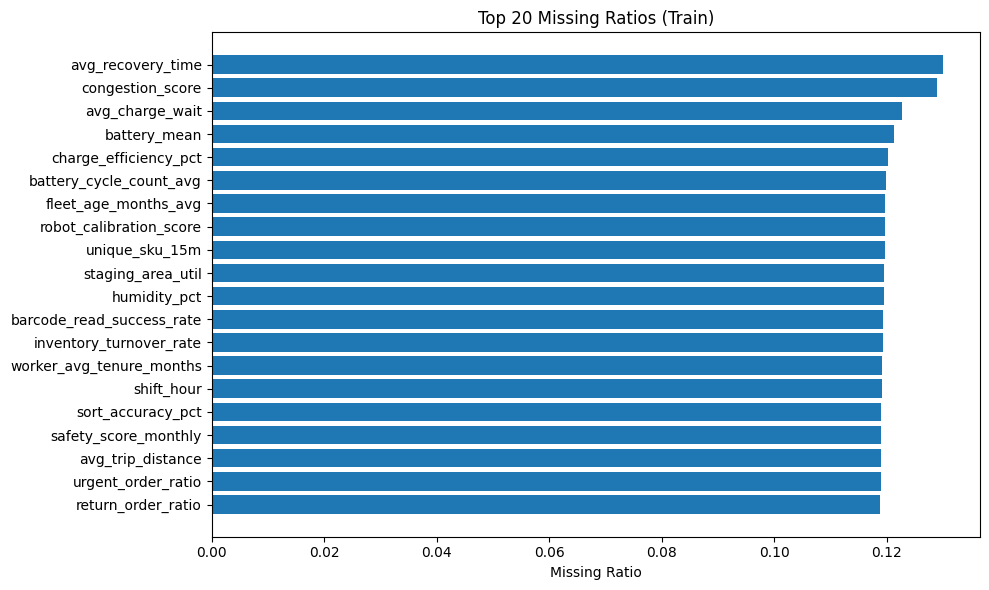

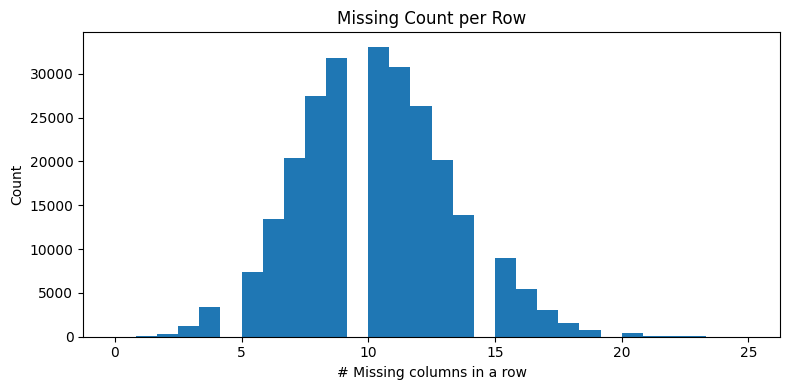

In [5]:
missing = train.isna().mean().sort_values(ascending=False).rename("missing_ratio")
missing_df = missing.reset_index().rename(columns={"index": "column"})
print("\n[Top 20 missing ratio]")
print(missing_df.head(20))

plt.figure(figsize=(10, 6))
top_miss = missing_df.head(20).iloc[::-1]
plt.barh(top_miss["column"], top_miss["missing_ratio"])
plt.title("Top 20 Missing Ratios (Train)")
plt.xlabel("Missing Ratio")
plt.tight_layout()
plt.show()

# 행 단위 결측 개수 분포
row_missing_cnt = train.isna().sum(axis=1)
plt.figure(figsize=(8, 4))
plt.hist(row_missing_cnt, bins=30)
plt.title("Missing Count per Row")
plt.xlabel("# Missing columns in a row")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 4. 타깃 기술통계 확인
### 이상치 파악


[Target describe]
count    250000.000000
mean         18.962296
std          27.351374
min           0.000000
1%            0.000000
5%            1.161278
50%           9.032652
95%          60.792706
99%         120.854721
max         715.858119
Name: avg_delay_minutes_next_30m, dtype: float64


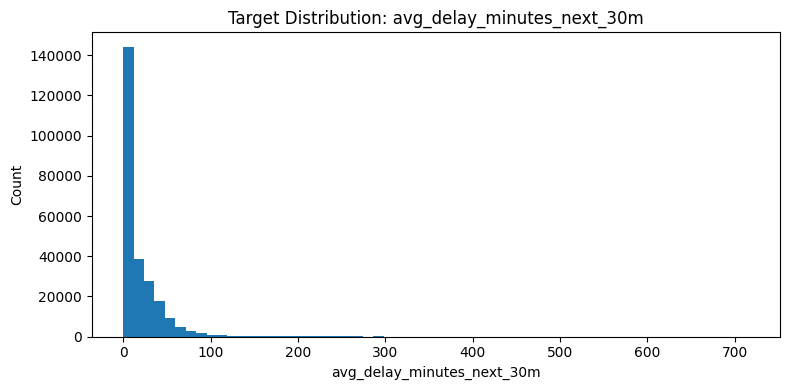

In [6]:
if TARGET_COL in train.columns:
    print("\n[Target describe]")
    print(train[TARGET_COL].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))

    plt.figure(figsize=(8, 4))
    plt.hist(train[TARGET_COL].dropna(), bins=60)
    plt.title(f"Target Distribution: {TARGET_COL}")
    plt.xlabel(TARGET_COL)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

### 5. 수치형 컬럼과 타깃 상관계수 확인


[Top 20 abs corr with target]
                        column  corr_with_target
0            low_battery_ratio          0.366073
1                 battery_mean         -0.358886
2                   robot_idle         -0.349311
3             order_inflow_15m          0.341754
4               robot_charging          0.320406
5             max_zone_density          0.310816
6                  battery_std          0.308313
7             congestion_score          0.300357
8            sku_concentration          0.291888
9           urgent_order_ratio          0.271079
10         charge_queue_length          0.261425
11             avg_charge_wait          0.251458
12          near_collision_15m          0.242848
13              unique_sku_15m          0.229013
14            blocked_path_15m          0.220499
15           loading_dock_util          0.213132
16           robot_utilization          0.210818
17            heavy_item_ratio          0.210314
18             fault_count_15m        

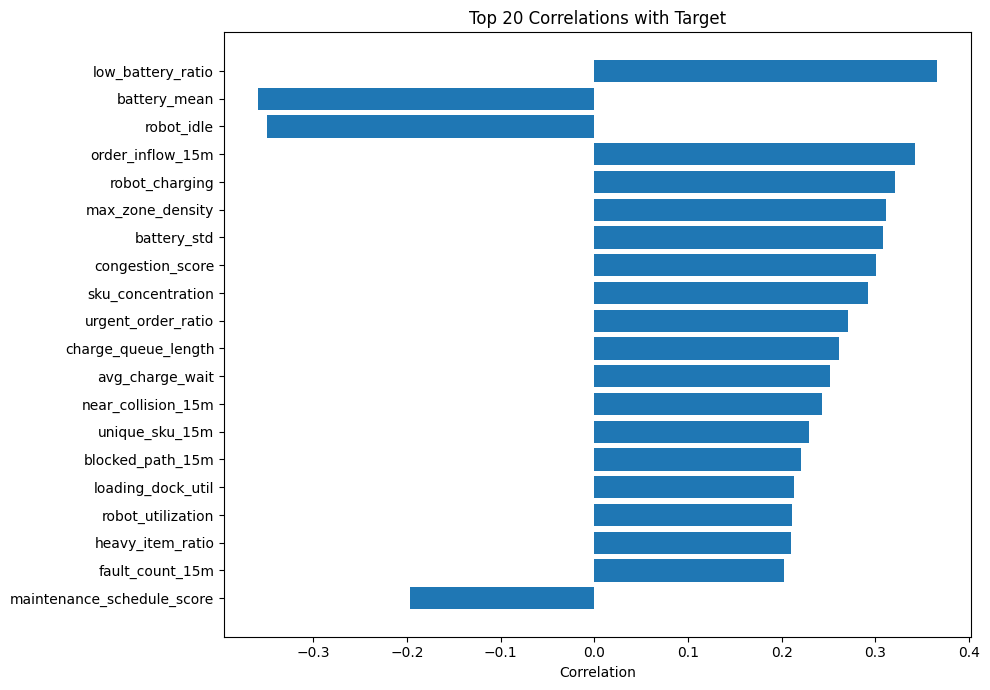

In [7]:
if TARGET_COL in train.columns:
    corr = train[num_cols].corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=np.abs, ascending=False)
    corr_df = corr.rename("corr_with_target").reset_index().rename(columns={"index": "column"})
    print("\n[Top 20 abs corr with target]")
    print(corr_df.head(20))

    plt.figure(figsize=(10, 7))
    top_corr = corr_df.head(20).iloc[::-1]
    plt.barh(top_corr["column"], top_corr["corr_with_target"])
    plt.title("Top 20 Correlations with Target")
    plt.xlabel("Correlation")
    plt.tight_layout()
    plt.show()

### 타깃 상관 높은 피처 분포를 개별 확인

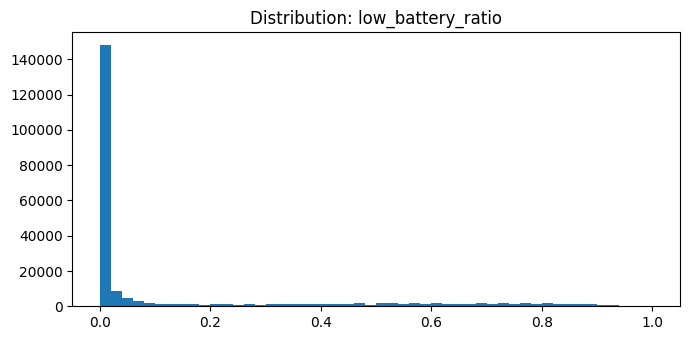

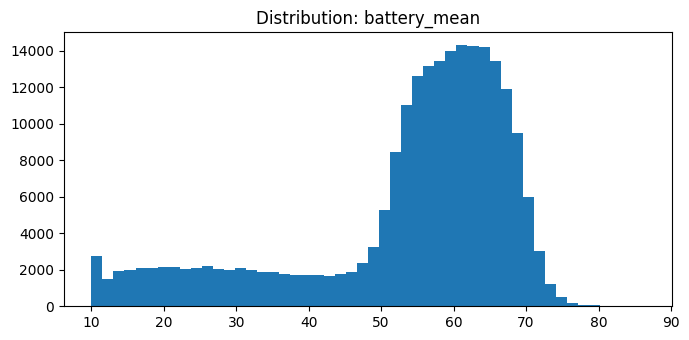

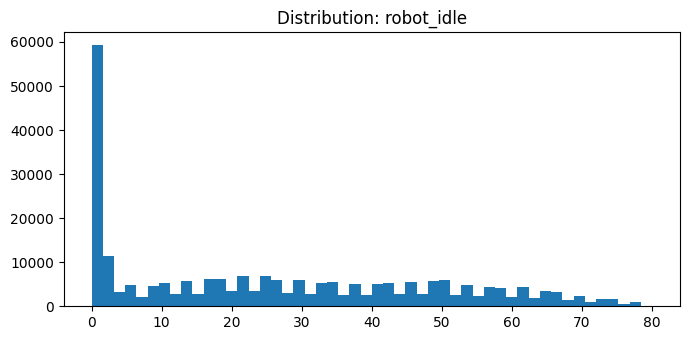

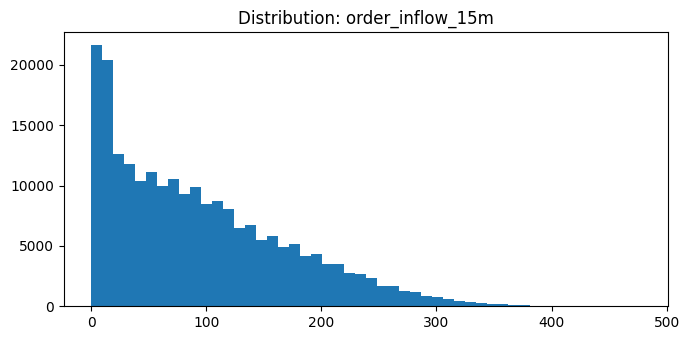

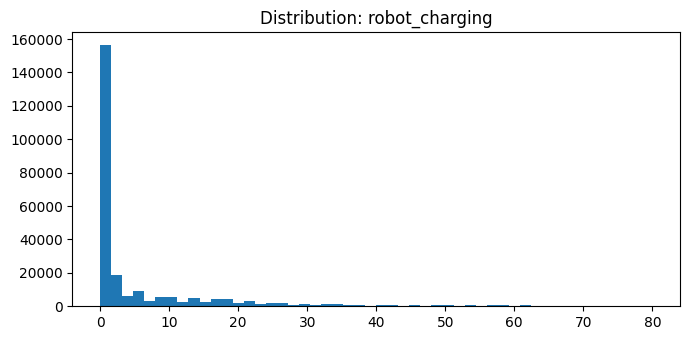

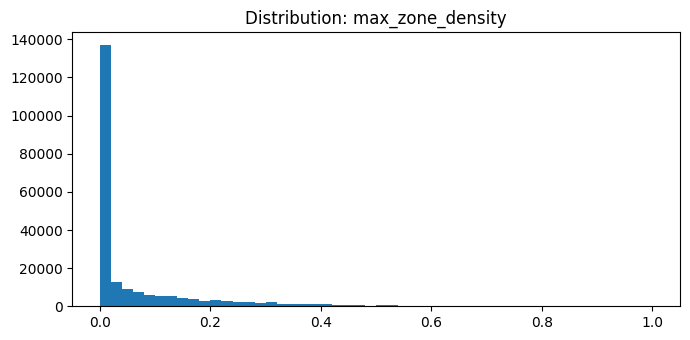

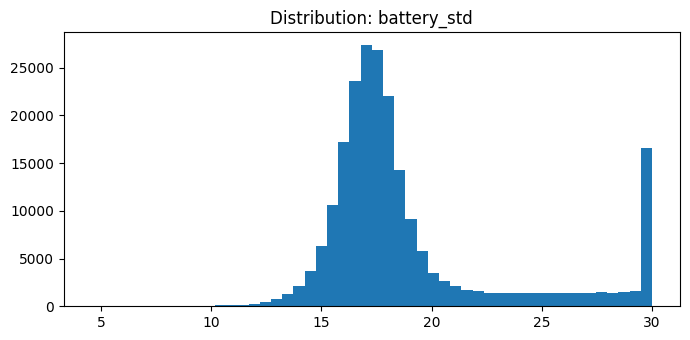

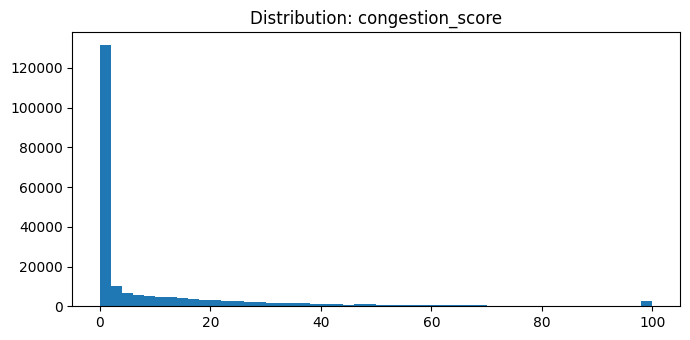

In [10]:
if TARGET_COL in train.columns:
    top_features = corr_df["column"].head(8).tolist()
else:
    top_features = num_cols[:8]

for c in top_features:
    plt.figure(figsize=(7, 3.5))
    x = train[c].dropna()
    if HAS_SNS:
        sns.histplot(x, bins=50, kde=True)
    else:
        plt.hist(x, bins=50)
    plt.title(f"Distribution: {c}")
    plt.tight_layout()
    plt.show()

### 범주형/ID형 컬럼별 고유값 수와 고유비율 확인

In [11]:
print("\n[Categorical / ID-like columns summary]")
for c in cat_cols:
    nunique = train[c].nunique(dropna=True)
    ratio = nunique / len(train)
    print(f"{c:20s} nunique={nunique:7d} unique_ratio={ratio:.4f}")

# scenario/layout train-test overlap (있으면)
for c in ["scenario_id", "layout_id"]:
    if c in train.columns and c in test.columns:
        tr_set = set(train[c].dropna().unique())
        te_set = set(test[c].dropna().unique())
        overlap = len(tr_set & te_set)
        print(f"\n[{c}] train={len(tr_set)}, test={len(te_set)}, overlap={overlap}, test_unseen={len(te_set-tr_set)}")


[Categorical / ID-like columns summary]
ID                   nunique= 250000 unique_ratio=1.0000
layout_id            nunique=    250 unique_ratio=0.0010
scenario_id          nunique=  10000 unique_ratio=0.0400

[scenario_id] train=10000, test=2000, overlap=0, test_unseen=2000

[layout_id] train=250, test=100, overlap=50, test_unseen=50


In [ ]:
# missing_df.to_csv("./eda_missing_ratio.csv", index=False)
# if TARGET_COL in train.columns:
#     corr_df.to_csv("./eda_target_corr.csv", index=False)

# print("\nEDA done. Saved: ./eda_missing_ratio.csv, ./eda_target_corr.csv")